<a href="https://colab.research.google.com/github/imredi12/Challenge-AluraLatam-TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📜Introducción

Se busca comprender el fenómeno de la evasión de clientes (churn) de la empresa TelecomX, buscando así reducir la pérdida de clientes a través del análisis exploratorio de datos (EDA)

#📌 Extracción



In [44]:
import requests
import json
import pandas as pd
import numpy as np

url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [45]:
datos = pd.read_json(url)
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


### Información del DataFrame

In [46]:
print(datos.head())
print(datos.info())
print(datos.columns)

   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecurity': '...   
2  {'InternetService': 'Fiber optic', 'OnlineSecu...   
3  {'I

#🔧 Transformación

✅ Explorar las columnas del dataset y verificar sus tipos de datos.

✅ Consultar el diccionario para comprender mejor el significado de las variables.

✅ Identificar las columnas más relevantes para el análisis de evasión.

In [47]:
# Expandiendo customer
customer_datos = pd.json_normalize(datos['customer'])
customer_datos.columns = ['customer_' + col for col in customer_datos.columns]

# Expandiendo phone
phone_datos = pd.json_normalize(datos['phone'])
phone_datos.columns = ['phone_' + col for col in phone_datos.columns]

# Expandiendo internet
internet_datos = pd.json_normalize(datos['internet'])
internet_datos.columns = ['internet_' + col for col in internet_datos.columns]

# Expandiendo account
account_datos = pd.json_normalize(datos['account'])
account_datos.columns = ['account_' + col for col in account_datos.columns]

In [48]:
# Uniendo las columnas expandidas al DataFrame
datos_norm = pd.concat([datos, customer_datos, phone_datos, internet_datos, account_datos], axis=1)

# Eliminarndo las columnas expandidas del DataFrame
datos_norm.drop(columns=['customer', 'phone', 'internet', 'account'], inplace=True)

### Luego de transformar, chequeamos el df nuevamente

In [49]:
datos_norm.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [50]:
datos_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

Pongo en revisión account_Charges.Total, siendo este una columna de valores numéricos que está siendo tomada como tipo de valor "object"

In [51]:
datos_norm['account_Charges.Total'].value_counts()

,count
account_Charges.Total,
20.2,11
,11
19.75,9
19.55,9
19.9,9
...,...
1993.2,1
72.1,1
1237.85,1


In [52]:
#Eliminando los caracteres que me pueden impedir el la transformación a float, aseguro el proceso
datos_norm['account_Charges.Total'] = datos_norm['account_Charges.Total'].str.replace(',', '').replace('$', '').replace(' ', '').replace('', None)
#Tranformo a float
datos_norm['account_Charges.Total'] = datos_norm['account_Charges.Total'].astype(np.float64)
#chequeo que haya salido bien
datos_norm['account_Charges.Total'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7267 entries, 0 to 7266
Series name: account_Charges.Total
Non-Null Count  Dtype  
--------------  -----  
7256 non-null   float64
dtypes: float64(1)
memory usage: 56.9 KB


In [53]:
datos_norm['account_Charges.Total'].isna().value_counts()

,count
account_Charges.Total,
False,7256
True,11


In [54]:
#Busco las filas que no tienen valores utilizables
total_nulos = datos_norm['account_Charges.Total'].isna()
datos_norm[total_nulos]

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [55]:
#Al parecer son clientes que recién se suscribieron a la compañía
#no aportarían relación relevante para el estudio, en este caso conviene eliminar esas filas.

datos_norm = datos_norm.drop(datos_norm[total_nulos].index, axis = 0)

#aplico reset al indice
datos_norm = datos_norm.reset_index(drop=True)

In [56]:
datos_norm['account_Charges.Total'].isna().value_counts()

,count
account_Charges.Total,
False,7256


Chequeo las demás columnas

In [57]:
datos_norm.sample(5)

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
4882,6691-CCIHA,No,Female,0,Yes,No,62,Yes,Yes,DSL,...,Yes,No,Yes,Yes,Yes,Two year,Yes,Electronic check,84.95,5150.55
3972,5445-GLVOT,No,Female,0,No,No,22,Yes,No,DSL,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,49.80,1049.05
141,0230-UBYPQ,No,Male,1,Yes,No,63,No,No phone service,DSL,...,No,No,Yes,No,No,One year,No,Bank transfer (automatic),36.10,2298.90
6599,9089-UOWJG,No,Female,0,Yes,Yes,12,Yes,No,DSL,...,No,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),58.35,740.55
4514,6199-IWKGC,No,Female,1,Yes,No,46,Yes,Yes,Fiber optic,...,No,No,Yes,Yes,Yes,One year,No,Electronic check,100.25,4753.85


In [58]:
datos_norm.nunique()

,0
customerID,7256
Churn,3
customer_gender,2
customer_SeniorCitizen,2
customer_Partner,2
customer_Dependents,2
customer_tenure,72
phone_PhoneService,2
phone_MultipleLines,3
internet_InternetService,3


In [59]:
#Muchas de esas columnas tienen solo dos valores (Yes/No), lo que sigue es analizar aquellas que tienen 3 y 4 datos
cols_revisar = datos_norm[['Churn','phone_MultipleLines','internet_InternetService',
                           'internet_OnlineSecurity','internet_OnlineBackup',
                           'internet_DeviceProtection','internet_TechSupport',
                           'internet_StreamingTV','internet_StreamingMovies',
                           'account_Contract','account_PaymentMethod']]

for col in cols_revisar:
    print(f"\n>>> {col} <<<")
    print(datos_norm[col].value_counts())


>>> Churn <<<
Churn
No     5163
Yes    1869
        224
Name: count, dtype: int64

>>> phone_MultipleLines <<<
phone_MultipleLines
No                  3490
Yes                 3061
No phone service     705
Name: count, dtype: int64

>>> internet_InternetService <<<
internet_InternetService
Fiber optic    3198
DSL            2483
No             1575
Name: count, dtype: int64

>>> internet_OnlineSecurity <<<
internet_OnlineSecurity
No                     3607
Yes                    2074
No internet service    1575
Name: count, dtype: int64

>>> internet_OnlineBackup <<<
internet_OnlineBackup
No                     3181
Yes                    2500
No internet service    1575
Name: count, dtype: int64

>>> internet_DeviceProtection <<<
internet_DeviceProtection
No                     3194
Yes                    2487
No internet service    1575
Name: count, dtype: int64

>>> internet_TechSupport <<<
internet_TechSupport
No                     3581
Yes                    2100
No internet se

In [60]:
#Redefino los datos, logrando así darle un valor binario a las filas

binarios = {
    # Columnas binarias simples Yes/No a 1/0
    'Churn': {'Yes': 1, 'No': 0},
    'customer_Partner': {'Yes': 1, 'No': 0},
    'customer_Dependents': {'Yes': 1, 'No': 0},
    'phone_PhoneService': {'Yes': 1, 'No': 0},
    'account_PaperlessBilling': {'Yes': 1, 'No': 0},

    # Columnas binarias con categoría especial (No phone/internet service) a 0, Yes a 1
    'phone_MultipleLines': {'Yes': 1, 'No': 0, 'No phone service': 0},
    'internet_OnlineSecurity': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'internet_OnlineBackup': {'Yes': 1, 'No': 0, 'No internet service': 0}, #
    'internet_DeviceProtection': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'internet_TechSupport': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'internet_StreamingTV': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'internet_StreamingMovies': {'Yes': 1, 'No': 0, 'No internet service': 0},

    #Columna descriptiva del cliente = gender
    'customer_gender' : {'Female': 1, 'Male': 0}
        }
    #La columna SeniorCitizen ya está en binario.

# Aplico los mapeos usando la herramienta .replace()
datos_norm.replace(binarios, inplace=True)


#verifico

datos_norm.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   customer_gender            7256 non-null   int64  
 3   customer_SeniorCitizen     7256 non-null   int64  
 4   customer_Partner           7256 non-null   int64  
 5   customer_Dependents        7256 non-null   int64  
 6   customer_tenure            7256 non-null   int64  
 7   phone_PhoneService         7256 non-null   int64  
 8   phone_MultipleLines        7256 non-null   int64  
 9   internet_InternetService   7256 non-null   object 
 10  internet_OnlineSecurity    7256 non-null   int64  
 11  internet_OnlineBackup      7256 non-null   int64  
 12  internet_DeviceProtection  7256 non-null   int64  
 13  internet_TechSupport       7256 non-null   int64

/tmp/ipykernel_172/2516885719.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos_norm.replace(binarios, inplace=True)


In [61]:
#La columna 'Churn' sigue apareciendo como tipo "object", la revisamos
datos['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [62]:
#Teniendo como referencia la cantidad de filas de churn "sin datos", necesitamos ver qué datos contienen las demás columnas
#las detallaré para ver por qué están vacías.

churn_blanc = datos['Churn'].str.strip() == ''
datos_norm[churn_blanc]

/tmp/ipykernel_172/2825212745.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  datos_norm[churn_blanc]


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
30,0047-ZHDTW,,1,0,0,0,11,1,1,Fiber optic,...,0,0,0,0,0,Month-to-month,1,Bank transfer (automatic),79.00,929.30
75,0120-YZLQA,,0,0,0,0,71,1,0,No,...,0,0,0,0,0,Two year,1,Credit card (automatic),19.90,1355.10
96,0154-QYHJU,,0,0,0,0,29,1,0,DSL,...,1,0,1,0,0,One year,1,Electronic check,58.75,1696.20
98,0162-RZGMZ,,1,1,0,0,5,1,0,DSL,...,1,0,1,0,0,Month-to-month,0,Credit card (automatic),59.90,287.85
175,0274-VVQOQ,,0,1,1,0,65,1,1,Fiber optic,...,1,1,0,1,1,One year,1,Bank transfer (automatic),103.15,6792.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7158,9853-JFZDU,0,1,0,1,0,35,1,0,DSL,...,1,0,1,0,0,Month-to-month,0,Electronic check,56.85,1861.10
7180,9891-NQDBD,0,1,0,1,0,28,1,1,No,...,0,0,0,0,0,One year,0,Mailed check,25.55,672.20
7211,9932-WBWIK,0,0,0,0,0,11,1,0,No,...,0,0,0,0,0,Month-to-month,0,Mailed check,20.35,215.25
7239,9970-QBCDA,0,1,0,0,0,6,1,0,No,...,0,0,0,0,0,Month-to-month,0,Credit card (automatic),19.70,129.55


In [63]:
print(datos_norm[churn_blanc].nunique())

customerID                   224
Churn                          3
customer_gender                2
customer_SeniorCitizen         2
customer_Partner               2
customer_Dependents            2
customer_tenure               65
phone_PhoneService             2
phone_MultipleLines            2
internet_InternetService       3
internet_OnlineSecurity        2
internet_OnlineBackup          2
internet_DeviceProtection      2
internet_TechSupport           2
internet_StreamingTV           2
internet_StreamingMovies       2
account_Contract               3
account_PaperlessBilling       2
account_PaymentMethod          4
account_Charges.Monthly      199
account_Charges.Total        221
dtype: int64


/tmp/ipykernel_172/3971158714.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(datos_norm[churn_blanc].nunique())


In [64]:
#Teniendo en cuenta la relevancia de los datos
#se coloca 0 a los datos de churn

datos_norm['Churn'] = datos_norm['Churn'].replace('', 0)

/tmp/ipykernel_172/641540712.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos_norm['Churn'] = datos_norm['Churn'].replace('', 0)


In [65]:
#Y ahora ya puedo cambiar el tipo de dato
datos_norm['Churn'] = datos_norm['Churn'].astype(np.int64)
datos_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   int64  
 2   customer_gender            7256 non-null   int64  
 3   customer_SeniorCitizen     7256 non-null   int64  
 4   customer_Partner           7256 non-null   int64  
 5   customer_Dependents        7256 non-null   int64  
 6   customer_tenure            7256 non-null   int64  
 7   phone_PhoneService         7256 non-null   int64  
 8   phone_MultipleLines        7256 non-null   int64  
 9   internet_InternetService   7256 non-null   object 
 10  internet_OnlineSecurity    7256 non-null   int64  
 11  internet_OnlineBackup      7256 non-null   int64  
 12  internet_DeviceProtection  7256 non-null   int64  
 13  internet_TechSupport       7256 non-null   int64

Quedan las columnas que tienen categorías dentro. Si bien podría asignarles un valor, sería mejor separar las categorías en una independiente, para que el análisis se pueda realizar mejor.

In [66]:
#Aplico la herramienta get_dummies para dividir las columnas

#InternetService
datos_norm = pd.get_dummies(datos_norm, columns=['internet_InternetService'], prefix=' ', dummy_na=False)

# Contract
datos_norm = pd.get_dummies(datos_norm, columns=['account_Contract'], prefix=' ', dummy_na=False)

# PaymentMethod
datos_norm = pd.get_dummies(datos_norm, columns=['account_PaymentMethod'], prefix=' ', dummy_na=False)

#compruebo

datos_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customerID                   7256 non-null   object 
 1   Churn                        7256 non-null   int64  
 2   customer_gender              7256 non-null   int64  
 3   customer_SeniorCitizen       7256 non-null   int64  
 4   customer_Partner             7256 non-null   int64  
 5   customer_Dependents          7256 non-null   int64  
 6   customer_tenure              7256 non-null   int64  
 7   phone_PhoneService           7256 non-null   int64  
 8   phone_MultipleLines          7256 non-null   int64  
 9   internet_OnlineSecurity      7256 non-null   int64  
 10  internet_OnlineBackup        7256 non-null   int64  
 11  internet_DeviceProtection    7256 non-null   int64  
 12  internet_TechSupport         7256 non-null   int64  
 13  internet_Streaming

In [67]:
#Al crearse las nuevas columnas como booleanas, conviene transformarlas en tipo int

for col in datos_norm.columns:
    if datos_norm[col].dtype == bool:
        datos_norm[col] = datos_norm[col].astype(int)

datos_norm.sample(5)

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,...,_DSL,_Fiber optic,_No,_Month-to-month,_One year,_Two year,_Bank transfer (automatic),_Credit card (automatic),_Electronic check,_Mailed check
4193,5774-XZTQC,0,1,0,1,1,7,1,0,0,...,0,0,1,1,0,0,0,0,0,1
250,0374-FIUCA,0,0,0,1,0,65,1,0,0,...,0,0,1,0,0,1,0,1,0,0
2082,2931-FSOHN,0,0,1,0,0,13,1,0,0,...,1,0,0,1,0,0,0,0,1,0
2453,3427-GGZZI,0,1,0,1,0,19,1,1,0,...,0,1,0,1,0,0,0,0,1,0
1462,2096-XOTMO,0,1,0,1,1,16,1,0,0,...,0,0,1,1,0,0,0,0,0,1


Ya con toda la información transformada y habiendo conseguido los datos útiles para analizar, destaco las columnas "Clientes ID" y "_No", éstas no contiene datos relevantes para el estudio. Aprovecho también para cambiar los nombres de las columnas al español para facilitar su lectura

In [68]:
datos_norm = datos_norm.drop(datos_norm[['customerID',' _No']], axis = 1)
datos_norm.columns.tolist()

['Churn',
 'customer_gender',
 'customer_SeniorCitizen',
 'customer_Partner',
 'customer_Dependents',
 'customer_tenure',
 'phone_PhoneService',
 'phone_MultipleLines',
 'internet_OnlineSecurity',
 'internet_OnlineBackup',
 'internet_DeviceProtection',
 'internet_TechSupport',
 'internet_StreamingTV',
 'internet_StreamingMovies',
 'account_PaperlessBilling',
 'account_Charges.Monthly',
 'account_Charges.Total',
 ' _DSL',
 ' _Fiber optic',
 ' _Month-to-month',
 ' _One year',
 ' _Two year',
 ' _Bank transfer (automatic)',
 ' _Credit card (automatic)',
 ' _Electronic check',
 ' _Mailed check']

In [69]:
datos_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Churn                        7256 non-null   int64  
 1   customer_gender              7256 non-null   int64  
 2   customer_SeniorCitizen       7256 non-null   int64  
 3   customer_Partner             7256 non-null   int64  
 4   customer_Dependents          7256 non-null   int64  
 5   customer_tenure              7256 non-null   int64  
 6   phone_PhoneService           7256 non-null   int64  
 7   phone_MultipleLines          7256 non-null   int64  
 8   internet_OnlineSecurity      7256 non-null   int64  
 9   internet_OnlineBackup        7256 non-null   int64  
 10  internet_DeviceProtection    7256 non-null   int64  
 11  internet_TechSupport         7256 non-null   int64  
 12  internet_StreamingTV         7256 non-null   int64  
 13  internet_Streaming

In [72]:
nombres_nuevos = {
    'Churn': 'Cancelación',
    'customer_gender': 'Género',
    'customer_SeniorCitizen': 'Jubilado',
    'customer_Partner': 'Pareja',
    'customer_Dependents': 'Dependientes',
    'customer_tenure': 'Meses_contrato',
    'phone_PhoneService': 'Servicio_telefonico',
    'phone_MultipleLines': 'Multiples_lineas',
    'internet_OnlineSecurity': 'Seguridad_Ol',
    'internet_OnlineBackup': 'Backup_Ol',
    'internet_DeviceProtection': 'Proteccion_dispositivo',
    'internet_TechSupport': 'Soporte_tecnico',
    'internet_StreamingTV': 'Streaming_TV',
    'internet_StreamingMovies': 'Streaming_peliculas',
    'account_PaperlessBilling': 'Facturacion_electronica',
    'account_Charges.Monthly': 'Cuentas_mensuales',
    'account_Charges.Total': 'Cuentas_totales',
    ' _DSL': 'DSL',
    ' _Fiber optic': 'Fibra_Optica',
    ' _Month-to-month': 'Contrato_Mensual',
    ' _One year': 'Contrato_Anual',
    ' _Two year': 'Contrato_Bianual',
    ' _Bank transfer (automatic)': 'Pago_Trf.Bancaria_Auto',
    ' _Credit card (automatic)': 'Pago_TCredito_Auto',
    ' _Electronic check': 'Pago_ChequeElectronico',
    ' _Mailed check': 'Pago_ChequePorCorreo',
}

datos_norm.rename(columns=nombres_nuevos, inplace=True)

datos_norm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7256 entries, 0 to 7255
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Cancelación              7256 non-null   int64  
 1   Género                   7256 non-null   int64  
 2   Jubilado                 7256 non-null   int64  
 3   Pareja                   7256 non-null   int64  
 4   Dependientes             7256 non-null   int64  
 5   Meses_contrato           7256 non-null   int64  
 6   Servicio_telefonico      7256 non-null   int64  
 7   Multiples_lineas         7256 non-null   int64  
 8   Seguridad_Ol             7256 non-null   int64  
 9   Backup_Ol                7256 non-null   int64  
 10  Proteccion_dispositivo   7256 non-null   int64  
 11  Soporte_tecnico          7256 non-null   int64  
 12  Streaming_TV             7256 non-null   int64  
 13  Streaming_peliculas      7256 non-null   int64  
 14  Facturacion_electronica 

In [77]:
# Muevo las columnas de Cuentas tanto mensuales como totales al final de la lista
# para facilitar el análisis, luego creo la columna de Cuentas_diarias

col_mover = ['Cuentas_mensuales', 'Cuentas_totales']
cols = [c for c in datos_norm.columns if c not in col_mover]
datos_norm = datos_norm[cols + col_mover]

In [79]:
dias_mes = 30
datos_norm['Cuentas_diarias'] = datos_norm.pop('Cuentas_diarias') / dias_mes
datos_norm.sample(5)

,Cancelación,Género,Jubilado,Pareja,Dependientes,Meses_contrato,Servicio_telefonico,Multiples_lineas,Seguridad_Ol,Backup_Ol,...,Contrato_Mensual,Contrato_Anual,Contrato_Bianual,Pago_Trf.Bancaria_Auto,Pago_TCredito_Auto,Pago_ChequeElectronico,Pago_ChequePorCorreo,Cuentas_mensuales,Cuentas_totales,Cuentas_diarias
6484,0,0,0,1,1,42,1,0,0,0,...,0,0,1,0,0,0,1,19.35,867.30,0.021500
6795,0,0,0,0,0,43,0,0,0,0,...,0,1,0,0,0,1,0,44.15,1931.30,0.049056
1193,0,1,0,0,0,17,1,1,0,0,...,1,0,0,0,0,0,1,69.00,1108.00,0.076667
3029,0,0,1,0,0,2,1,0,0,0,...,1,0,0,0,0,0,1,49.95,107.10,0.055500
2817,0,1,0,1,0,64,1,1,0,0,...,0,0,1,0,0,0,1,25.55,1714.95,0.028389


#📊 Carga y análisis

Comenzamos analizando los posibles motivos de la cancelación de los datos de los clientes

In [82]:
cancela = datos_norm['Cancelación'] == 1

no_cancela = datos_norm['Cancelación'] == 0

datos_norm[cancela].describe()

,Cancelación,Género,Jubilado,Pareja,Dependientes,Meses_contrato,Servicio_telefonico,Multiples_lineas,Seguridad_Ol,Backup_Ol,...,Contrato_Mensual,Contrato_Anual,Contrato_Bianual,Pago_Trf.Bancaria_Auto,Pago_TCredito_Auto,Pago_ChequeElectronico,Pago_ChequePorCorreo,Cuentas_mensuales,Cuentas_totales,Cuentas_diarias
count,1869.0,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,...,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000,1869.000000
mean,1.0,0.502408,0.254682,0.357945,0.174425,17.979133,0.909042,0.454789,0.157838,0.279829,...,0.885500,0.088818,0.025682,0.138042,0.124131,0.573034,0.164794,74.441332,1531.796094,0.082713
std,0.0,0.500128,0.435799,0.479524,0.379576,19.531123,0.287626,0.498085,0.364687,0.449035,...,0.318502,0.284556,0.158228,0.345036,0.329819,0.494770,0.371094,24.666053,1890.822994,0.027407
min,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.850000,18.850000,0.020944
25%,1.0,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.150000,134.500000,0.062389
50%,1.0,1.000000,0.000000,0.000000,0.000000,10.000000,1.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,79.650000,703.550000,0.088500
75%,1.0,1.000000,1.000000,1.000000,0.000000,29.000000,1.000000,1.000000,0.000000,1.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,94.200000,2331.300000,0.104667
max,1.0,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.350000,8684.800000,0.131500


In [83]:
datos_norm[no_cancela].describe()

,Cancelación,Género,Jubilado,Pareja,Dependientes,Meses_contrato,Servicio_telefonico,Multiples_lineas,Seguridad_Ol,Backup_Ol,...,Contrato_Mensual,Contrato_Anual,Contrato_Bianual,Pago_Trf.Bancaria_Auto,Pago_TCredito_Auto,Pago_ChequeElectronico,Pago_ChequePorCorreo,Cuentas_mensuales,Cuentas_totales,Cuentas_diarias
count,5387.0,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000,...,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000,5387.000000
mean,0.0,0.491554,0.131056,0.527195,0.342306,37.397253,0.900687,0.410433,0.330239,0.366995,...,0.436235,0.250975,0.312790,0.246705,0.247819,0.255058,0.250418,61.394932,2540.440867,0.068217
std,0.0,0.499975,0.337493,0.499306,0.474525,24.144085,0.299110,0.491958,0.470343,0.482030,...,0.495963,0.433614,0.463673,0.431134,0.431786,0.435935,0.433294,31.106744,2330.360507,0.034563
min,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.020278
25%,0.0,0.000000,0.000000,0.000000,0.000000,14.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.100000,568.000000,0.027889
50%,0.0,0.000000,0.000000,1.000000,0.000000,37.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.550000,1669.400000,0.071722
75%,0.0,1.000000,0.000000,1.000000,1.000000,61.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,88.700000,4247.825000,0.098556
max,0.0,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8672.450000,0.131944


Si bien podemos observar datos que indican los posibles motivos de cancelación, a continuación voy a graficar para un entendimiento más claro de los datos.

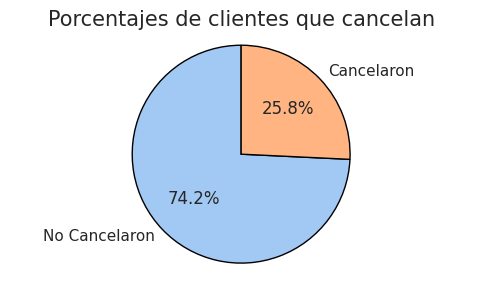

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

# Datos para el pie chart
valores = datos_norm['Cancelación'].value_counts()
etiquetas = ['No Cancelaron', 'Cancelaron']
colores = sns.color_palette("pastel")[:2]  # Colores suaves

# Gráfico circular
plt.figure(figsize=(5, 3))
plt.pie(valores, labels=etiquetas, autopct='%1.1f%%', startangle=90, colors=colores, wedgeprops={'edgecolor': 'black'})
plt.title('Porcentajes de clientes que cancelan', fontsize=15)
plt.axis('equal')
plt.tight_layout()

plt.savefig("porcentajes_cancelacion.png", dpi=300, bbox_inches='tight')

plt.show()

Comparando la cancelación vs tiempo y gasto mensual y diario

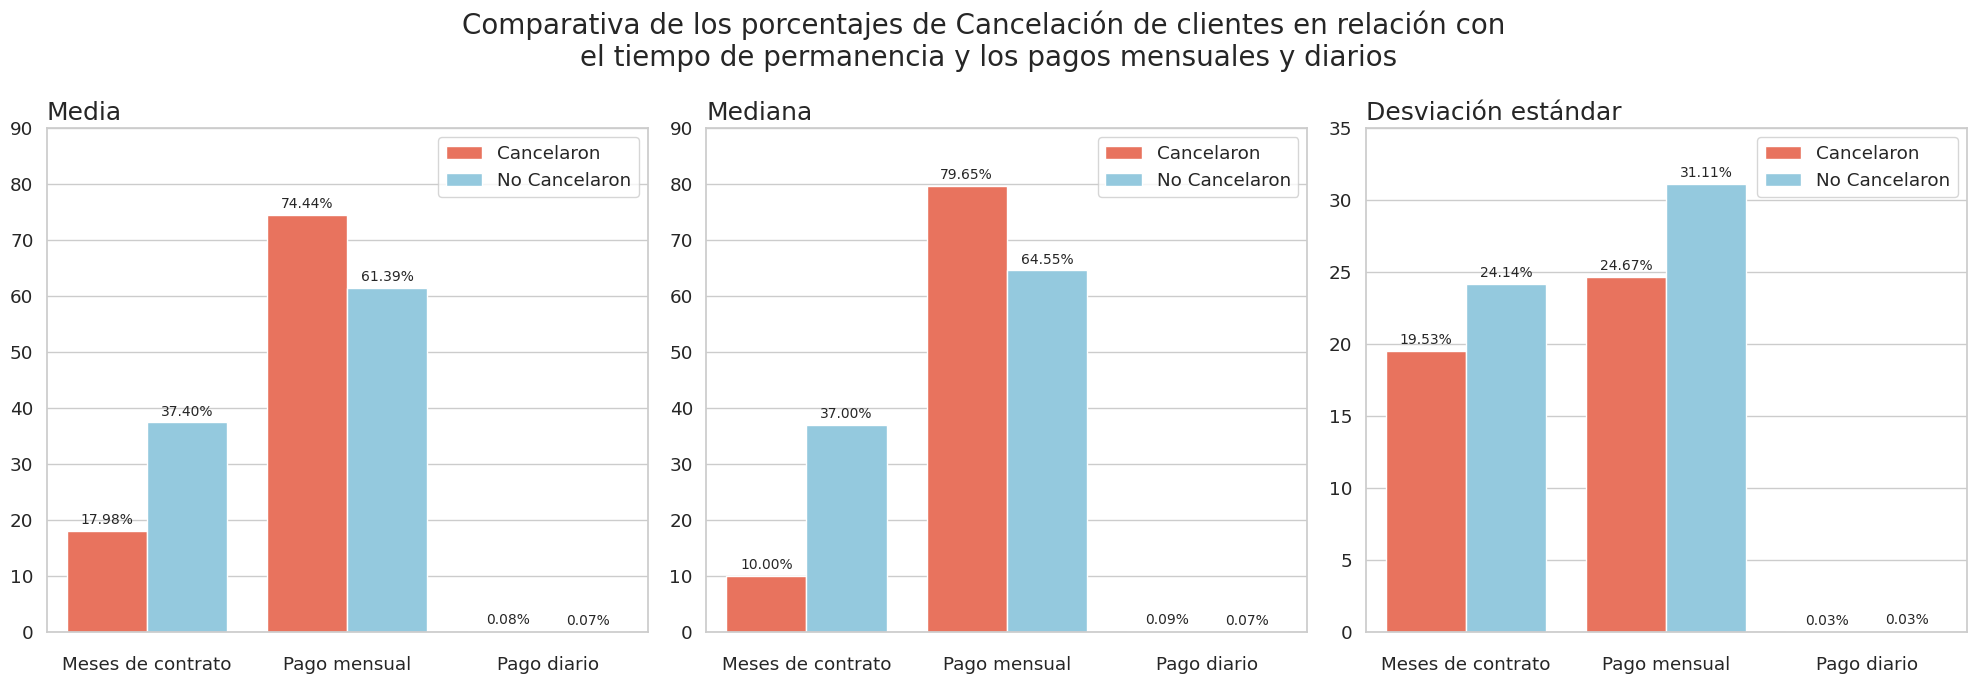

In [104]:
sns.set_theme(style="whitegrid")
sns.set_theme(style="whitegrid", font_scale=1.1)
colores = sns.color_palette("pastel")[:2]
sns.set_context("notebook", font_scale=1.2)

# Columnas a comparar
cols = ['Meses_contrato', 'Cuentas_mensuales', 'Cuentas_diarias']

nombres_personalizados = {
    'Meses_contrato': 'Meses de contrato',
    'Cuentas_mensuales': 'Pago mensual',
    'Cuentas_diarias': 'Pago diario'
}

# Función para calcular estadísticas por grupo
def resumen_estadisticas(datos_norm, columnas):
    lista = []
    for col in columnas:
        cancelaron = datos_norm[datos_norm['Cancelación'] == 1][col]
        no_cancelaron = datos_norm[datos_norm['Cancelación'] == 0][col]

        lista.append(['Media', col, 'Cancelaron', cancelaron.mean()])
        lista.append(['Media', col, 'No Cancelaron', no_cancelaron.mean()])
        lista.append(['Mediana', col, 'Cancelaron', cancelaron.median()])
        lista.append(['Mediana', col, 'No Cancelaron', no_cancelaron.median()])
        lista.append(['Desviación estándar', col, 'Cancelaron', cancelaron.std()])
        lista.append(['Desviación estándar', col, 'No Cancelaron', no_cancelaron.std()])

    df = pd.DataFrame(lista, columns=['Estadistica', 'Variable', 'Grupo', 'Valor'])
    return df

# Calculo el resumen
df_resumen = resumen_estadisticas(datos_norm, cols)

# Crear gráfico con subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)

# Gráficos por estadística
estadisticas = ['Media', 'Mediana', 'Desviación estándar']
colores = {'Cancelaron': 'tomato', 'No Cancelaron': 'skyblue'}

for i, estadistica in enumerate(estadisticas):
    df_plot = df_resumen[df_resumen['Estadistica'] == estadistica].copy()
    df_plot['Variable'] = df_plot['Variable'].map(nombres_personalizados)

    sns.barplot(data=df_plot, x='Variable', y='Valor', hue='Grupo',
                palette=colores, ax=axes[i])

    axes[i].set_title(estadistica, fontsize = 18, loc ='left')


    # Ajusto el eje Y según el tipo de estadística
    if estadistica == 'Media':
        axes[i].set_ylim(0, 90)
    elif estadistica == 'Mediana':
        axes[i].set_ylim(0, 90)
    elif estadistica == 'Desviación estándar':
        axes[i].set_ylim(0, 35)

    axes[i].set_ylabel('',)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x',size = 14)
    axes[i].legend(title = '',loc='upper right')

    # Mostrar los valores encima de las barras
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f%%', label_type='edge', padding=3, fontsize = 10)

# Título general y ajuste del espacio superior
plt.suptitle('Comparativa de los porcentajes de Cancelación de clientes en relación con \nel tiempo de permanencia y los pagos mensuales y diarios', fontsize=20)
plt.subplots_adjust(top=0.85)
plt.tight_layout()

plt.savefig("comparacion_pago_mes_dia_y_tiempo.png", dpi=300, bbox_inches='tight')


plt.show()


Teniendo en cuenta la gráfica podemos observar que los que cancelaron tenían un porcentaje más elevado de pago mensual.

##Comparando las cancelaciones por tipo de servicio
creando una lista con las columnas de los servicios que necesito comparar

In [112]:
servicios = ['Servicio_telefonico', 'Multiples_lineas', 'DSL', 'Fibra_Optica']

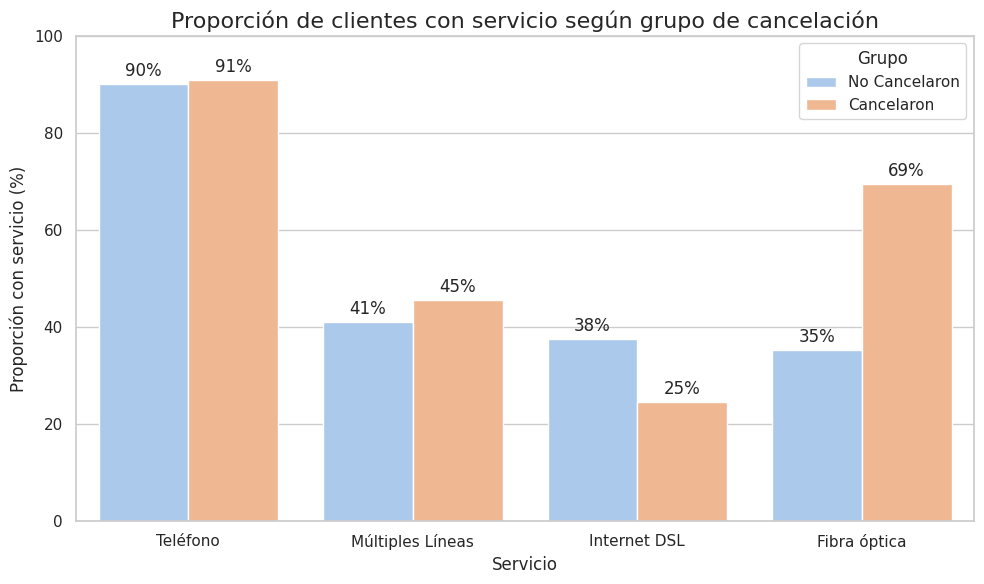

In [113]:
#Y grafico en base a esa lista
sns.set_theme(style="whitegrid")

# Servicios
nombres_barras = {
    'Servicio_telefonico': 'Teléfono',
    'Multiples_lineas': 'Múltiples Líneas',
    'DSL': 'Internet DSL',
    'Fibra_Optica': 'Fibra óptica'
}

# Preparar DataFrame con proporciones por grupo
df_resultados = []

for servicio in servicios:
    for grupo in [0, 1]:  # 0 = No Cancelaron, 1 = Cancelaron
        subset = datos_norm[datos_norm['Cancelación'] == grupo]
        total = len(subset)
        con_servicio = subset[servicio].sum()
        proporcion = (con_servicio / total) * 100 if total > 0 else 0  # → en porcentaje

        df_resultados.append([
            nombres_barras[servicio],
            'Cancelaron' if grupo == 1 else 'No Cancelaron',
            proporcion
        ])

df_servicios = pd.DataFrame(df_resultados, columns=['Servicio', 'Grupo', 'Proporcion'])

# Grafico
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_servicios,
    x='Servicio',
    y='Proporcion',
    hue='Grupo',
    palette='pastel',
    errorbar=None
)

plt.title('Proporción de clientes con servicio según grupo de cancelación', fontsize=16)
plt.xlabel('Servicio')
plt.ylabel('Proporción con servicio (%)')
plt.ylim(0, 100)

# Etiquetas de porcentaje sobre cada barra
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f%%', label_type='edge', padding=3)

plt.tight_layout()
plt.show()


Podemos observar que:
1.   En múltiples líneas hay una ligera tendencia de cancelación
2.   Aunque en el servicio DSL la tendencia a cancelar fue mucho menor
1.   En el servicio de Fibra óptica la cancelación fue muchísimo mayor con respecto a los demás servicios







In [114]:
#Ahora continúo revisando los servicios adicionales al servicio de internet
servicios_adicionales = ['Seguridad_Ol', 'Backup_Ol', 'Proteccion_dispositivo', 'Soporte_tecnico', 'Streaming_TV', 'Streaming_peliculas']

nombres_adicionales = {
    'Seguridad_Ol': 'Seguridad Online',
    'Backup_Ol': 'Backup Online',
    'Proteccion_dispositivo': 'Proteccion Dispositivo',
    'Soporte_tecnico': 'Soporte técnico',
    'Streaming_TV': 'Streaming TV',
    'Streaming_peliculas': 'Streaming películas'
       }

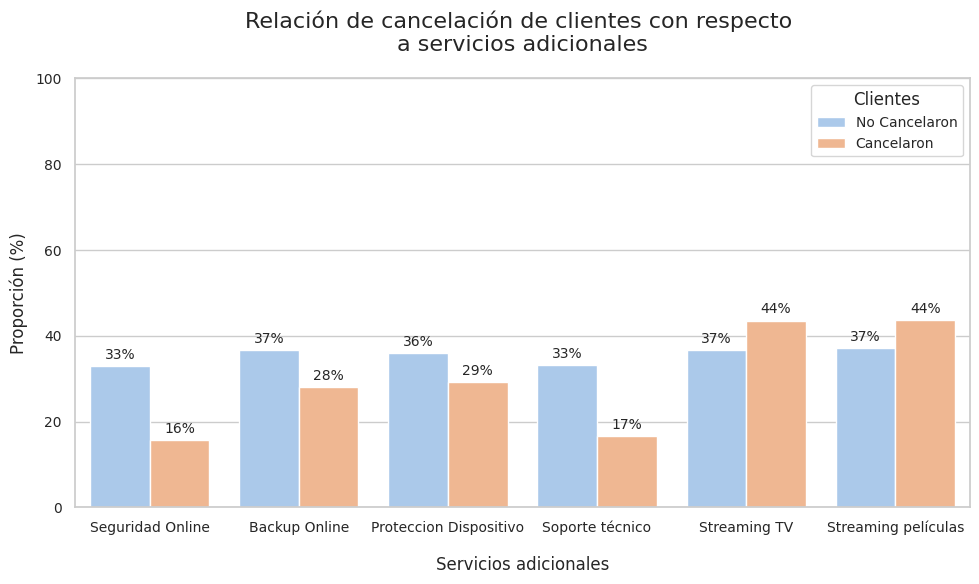

In [115]:
df_adicionales = []

for adicional in servicios_adicionales:
    for grupo in [0, 1]:  # 0 = No Cancelaron, 1 = Cancelaron
        subset = datos_norm[datos_norm['Cancelación'] == grupo]
        total = len(subset)
        con_el_servicio = subset[adicional].sum()
        proporcion = (con_el_servicio / total) * 100 if total > 0 else 0  # → en porcentaje

        df_adicionales.append([
            nombres_adicionales[adicional],
            'Cancelaron' if grupo == 1 else 'No Cancelaron',
            proporcion
        ])

df_serv_adicionales = pd.DataFrame(df_adicionales, columns=['Adicional', 'Grupo', 'Proporcion'])

# Grafico
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_serv_adicionales,
    x='Adicional',
    y='Proporcion',
    hue='Grupo',
    palette='pastel',
    errorbar=None
)

plt.title('Relación de cancelación de clientes con respecto \na servicios adicionales', fontsize=16, pad = 20)
plt.xlabel('Servicios adicionales', labelpad = 15)
plt.ylabel('Proporción (%)', labelpad = 5)
plt.ylim(0, 100)
plt.legend(title='Clientes', fontsize = 10)
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

# Etiquetas de porcentaje sobre cada barra
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f%%', label_type='edge', padding=3, fontsize = 10)

plt.tight_layout()
plt.show()

Por lo que podemos observar, en los servicios de streaming TV y de Películas hay una tendencia de cancelación, contrario a los demás servicios que se ven en la gráfica

## Cancelación por tipo de pago

In [116]:
metodo_pago = ['Pago_Trf.Bancaria_Auto', 'Pago_TCredito_Auto', 'Pago_ChequeElectronico', 'Pago_ChequePorCorreo']


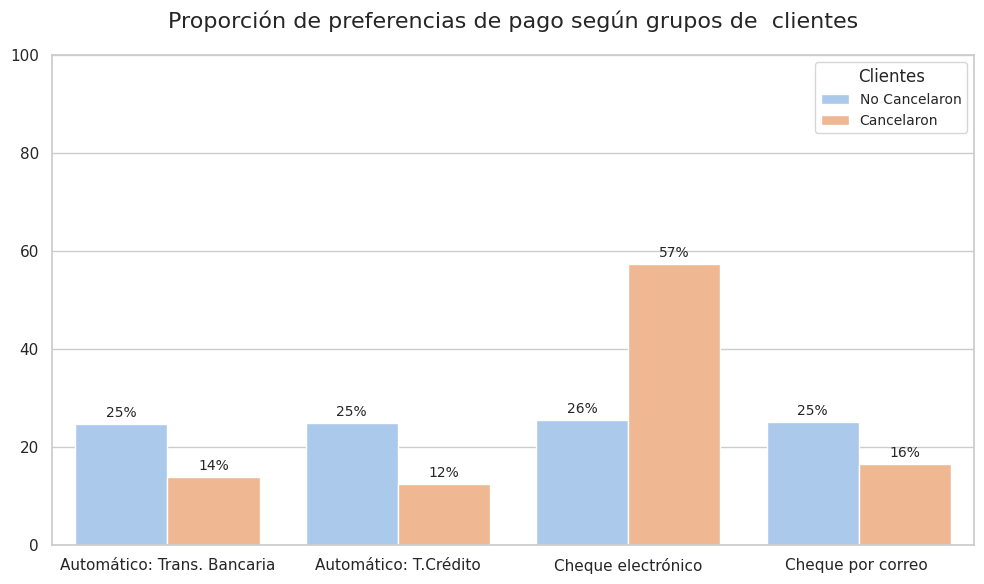

In [117]:
sns.set_theme(style="whitegrid")

#nombres para las barras
nombres_metodos = {
    'Pago_Trf.Bancaria_Auto': 'Automático: Trans. Bancaria',
    'Pago_TCredito_Auto': 'Automático: T.Crédito',
    'Pago_ChequeElectronico': 'Cheque electrónico',
    'Pago_ChequePorCorreo': 'Cheque por correo '
}

# Preparar DataFrame con proporciones por grupo
df_pagos = []

for metodo in metodo_pago:
    for grupo in [0, 1]:  # 0 = No Cancelaron, 1 = Cancelaron
        subset = datos_norm[datos_norm['Cancelación'] == grupo]
        total = len(subset)
        preferencia_pago = subset[metodo].sum()
        proporcion = (preferencia_pago / total) * 100 if total > 0 else 0  # → en porcentaje

        df_pagos.append([
            nombres_metodos[metodo],
            'Cancelaron' if grupo == 1 else 'No Cancelaron',
            proporcion
        ])

df_metodo_pago = pd.DataFrame(df_pagos, columns=['Metodo', 'Grupo', 'Proporcion'])

# Grafico
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_metodo_pago,
    x='Metodo',
    y='Proporcion',
    hue='Grupo',
    palette='pastel',
    errorbar=None
)

plt.title('Proporción de preferencias de pago según grupos de  clientes', fontsize=16, pad = 20)
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Clientes', fontsize = 10)

plt.ylim(0, 100)

# Etiquetas de porcentaje sobre cada barra
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.0f%%', label_type='edge', padding=3, fontsize = 10)

plt.savefig("grafico_metodos de pago.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

Por lo que se observa, la cancelación de quienes realizan el pago por Cheque electrónico es muy grande. Contrario a quienes realizan el pago automático, quienes se nota una alta fidelidad de servicio.

## Comparativa por tipo de contrato

In [118]:
contratos = ['Contrato_Mensual', 'Contrato_Anual', 'Contrato_Bianual']

#diccionario con nomres de las etiquetas
nombres_contratos = {
    'Contrato_Mensual': 'Contrato mes a mes',
    'Contrato_Anual': 'Contrato a 1 año',
    'Contrato_Bianual': 'Contrato a 2 años',
}

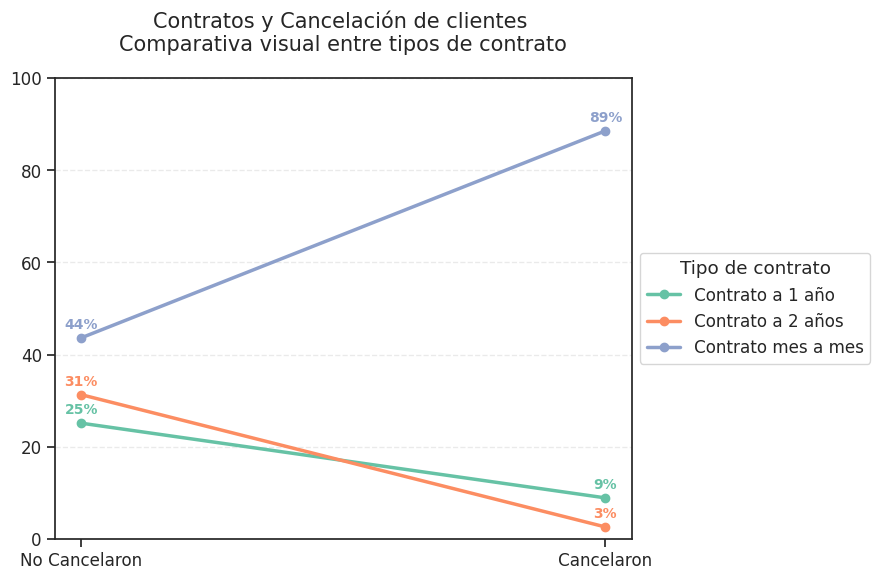

In [119]:
sns.set_theme(style="ticks", font_scale=1.1)


datos_slope = []
for contrato in contratos:
    for grupo in [0, 1]:  # 0 = No Cancelaron, 1 = Cancelaron
        subset = datos_norm[datos_norm['Cancelación'] == grupo]
        total = len(subset)
        con_contrato = subset[contrato].sum()
        proporcion = (con_contrato / total) * 100 if total > 0 else 0

        datos_slope.append([
            nombres_contratos[contrato],
            'No Cancelaron' if grupo == 0 else 'Cancelaron',
            proporcion
        ])

df_slope = pd.DataFrame(datos_slope, columns=['Contrato', 'Grupo', 'Proporcion'])
pivot = df_slope.pivot(index='Contrato', columns='Grupo', values='Proporcion')

# Grafico
plt.figure(figsize=(9, 6))
colores = sns.color_palette("Set2", n_colors=len(pivot))

for (contrato, fila), color in zip(pivot.iterrows(), colores):
    plt.plot(['No Cancelaron', 'Cancelaron'],
             [fila['No Cancelaron'], fila['Cancelaron']],
             marker='o', linewidth=2.5, color=color, label=contrato)

    # Etiquetas en los puntos
    plt.text('No Cancelaron', fila['No Cancelaron'] + 2, f"{fila['No Cancelaron']:.0f}%",
             ha='center', fontsize=10, weight='bold', color=color)
    plt.text('Cancelaron', fila['Cancelaron'] + 2, f"{fila['Cancelaron']:.0f}%",
             ha='center', fontsize=10, weight='bold', color=color)

# Estética del gráfico
plt.title('Contratos y Cancelación de clientes \nComparativa visual entre tipos de contrato',
          fontsize=15, loc='center', pad=20)
plt.ylabel('')
plt.ylim(0, 100)
plt.xticks(['No Cancelaron', 'Cancelaron'])
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(title='Tipo de contrato', loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

plt.savefig("grafico_tipo_contrato.png", dpi=300, bbox_inches='tight')

plt.show()

Suelen fidelizar mucho más a los clientes con contrato de mes a mes.

## Comparación por tipo de cliente

In [120]:
clientes = ['Género','Jubilado','Dependientes']

# Defino los valores
tipos_clientes = {
      'Género': {0: 'Hombre', 1: 'Mujer'},
      'Jubilado': {0: 'No Jubilado', 1: 'Jubilado'},
    'Dependientes': {0: 'Sin dependientes', 1: 'Con dependientes'}
}

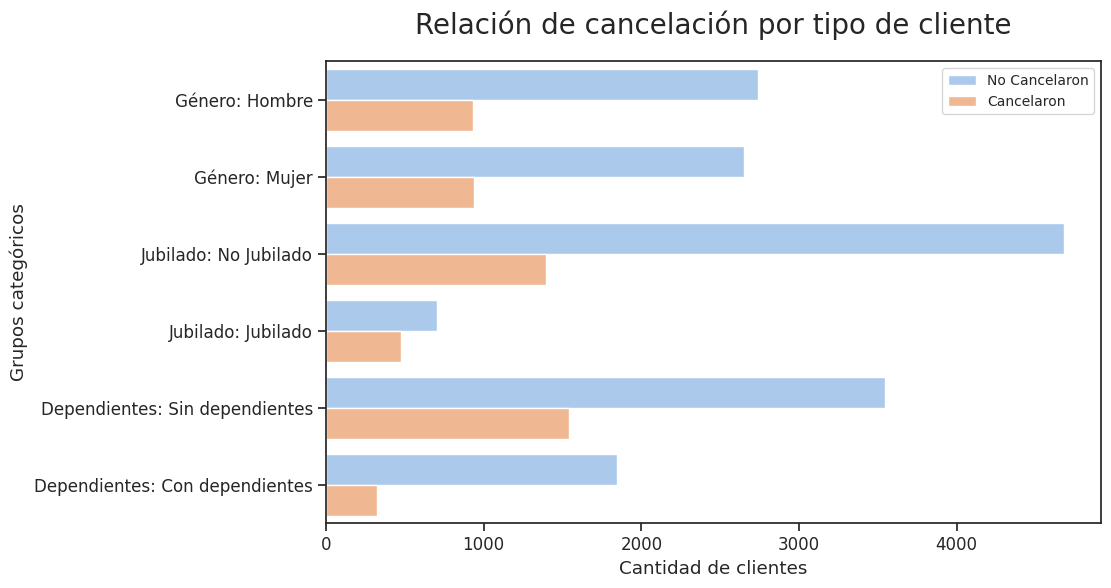

In [122]:
datos_clientes = []

for var in clientes:
    nombre_legible = var

    for estado in [0, 1]:
        for grupo in [0, 1]:  # 0 = No Cancelaron, 1 = Cancelaron
            subset = datos_norm[(datos_norm[var] == estado) & (datos_norm['Cancelación'] == grupo)]
            total = len(subset)
            datos_clientes.append([

                f"{var}: {tipos_clientes[var][estado]}",
                'Cancelaron' if grupo == 1 else 'No Cancelaron',
                total
            ])

df_clientes = pd.DataFrame(datos_clientes, columns=['Grupo', 'Estado', 'Cantidad'])

# Grafico
plt.figure(figsize=(10, 6))
sns.barplot(data=df_clientes, y='Grupo', x='Cantidad', hue='Estado', palette='pastel')

plt.title('Relación de cancelación por tipo de cliente', fontsize=20, pad=20)
plt.xlabel('Cantidad de clientes')
plt.ylabel('Grupos categóricos')
plt.xticks(fontsize=12)
plt.legend(fontsize=10)
plt.show()

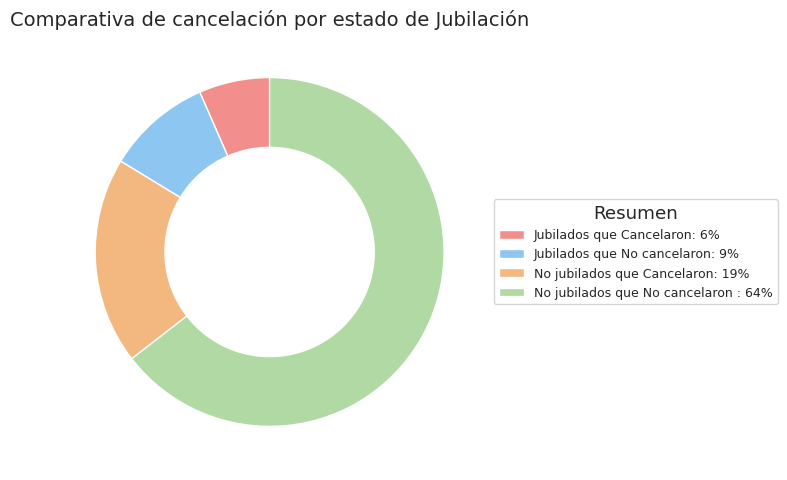

In [123]:
# Defino etiquetas y colores
etiquetas = [
    'Jubilados que Cancelaron',
    'Jubilados que No cancelaron',
    'No jubilados que Cancelaron',
    'No jubilados que No cancelaron '
]

valores = [
    len(datos_norm[(datos_norm['Jubilado'] == 1) & (datos_norm['Cancelación'] == 1)]),
    len(datos_norm[(datos_norm['Jubilado'] == 1) & (datos_norm['Cancelación'] == 0)]),
    len(datos_norm[(datos_norm['Jubilado'] == 0) & (datos_norm['Cancelación'] == 1)]),
    len(datos_norm[(datos_norm['Jubilado'] == 0) & (datos_norm['Cancelación'] == 0)])
]

# Calcular porcentajes
porcentajes = [v / sum(valores) * 100 for v in valores]
etiquetas_con_porcentaje = [
    f'{label}: {int(p)}%' for label, p in zip(etiquetas, porcentajes)
]

colores = ['#F28E8C', '#8EC6F2', '#F2B880', '#B0D9A3']

# Gráfica
fig, ax = plt.subplots(figsize=(7, 5))

# Gráfico sin etiquetas flotantes
wedges, _ = ax.pie(
    valores,
    startangle=90,
    colors=colores,
    wedgeprops=dict(width=0.4, edgecolor='white')
)

# Leyenda con porcentaje
ax.legend(wedges, etiquetas_con_porcentaje,
          title="Resumen", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)

plt.title('Comparativa de cancelación por estado de Jubilación', fontsize=14)
plt.tight_layout()

plt.savefig("clientes_jubilados.png", dpi=300, bbox_inches='tight')

plt.show()

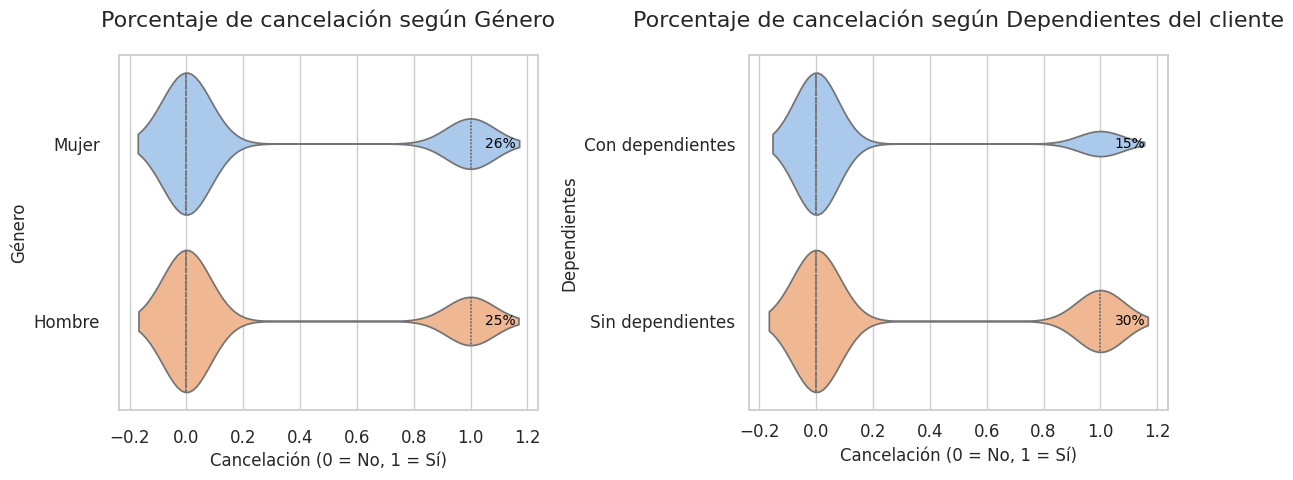

In [129]:
sns.set_theme(style="whitegrid", font_scale=1.1)

# Etiquetas legibles
datos_norm['Género_txt'] = datos_norm['Género'].map({0: 'Hombre', 1: 'Mujer'})
datos_norm['Dependientes_txt'] = datos_norm['Dependientes'].map({0: 'Sin dependientes', 1: 'Con dependientes'})

# subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# Gráfico 1: Género
sns.violinplot(
    data=datos_norm,
    x='Cancelación',
    y='Género_txt',
    hue='Género_txt',
    palette='pastel',
    inner='quartile',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Porcentaje de cancelación según Género', fontsize = 16, pad = 20)
axes[0].set_xlabel('Cancelación (0 = No, 1 = Sí)', fontsize = 12)
axes[0].set_ylabel('Género', fontsize = 12)
axes[0].tick_params(axis='x',size = 10)
axes[0].tick_params(axis='y',size = 10)



# Añadir porcentajes en el gráfico
for i, genero in enumerate(['Mujer', 'Hombre']):
    total = len(datos_norm[datos_norm['Género_txt'] == genero])
    cancelados = datos_norm[(datos_norm['Género_txt'] == genero) & (datos_norm['Cancelación'] == 1)]
    porcentaje = (len(cancelados) / total) * 100
    axes[0].text(1.05, i, f'{porcentaje:.0f}%', va='center', fontsize=10, color='black')


# Gráfico 2: Dependientes
sns.violinplot(
    data=datos_norm,
    x='Cancelación',
    y='Dependientes_txt',
    hue='Dependientes_txt',
    palette='pastel',
    inner='quartile',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Porcentaje de cancelación según Dependientes del cliente', fontsize = 16, pad = 20 )
axes[1].set_xlabel('Cancelación (0 = No, 1 = Sí)', fontsize = 12)
axes[1].set_ylabel('Dependientes', fontsize = 12)
axes[0].tick_params(axis='x',size = 10)
axes[0].tick_params(axis='y',size = 10)


# Añadir porcentajes manuales
for i, dep in enumerate(['Con dependientes', 'Sin dependientes']):
    total = len(datos_norm[datos_norm['Dependientes_txt'] == dep])
    cancelados = datos_norm[(datos_norm['Dependientes_txt'] == dep) & (datos_norm['Cancelación'] == 1)]
    porcentaje = (len(cancelados) / total) * 100
    axes[1].text(1.05, i, f'{porcentaje:.0f}%', va='center', fontsize=10, color='black')


plt.tight_layout()

plt.savefig("genero_y_dependencia.png", dpi=300, bbox_inches='tight')

plt.show()

## Cancelación por tiempo de contrato y gasto total

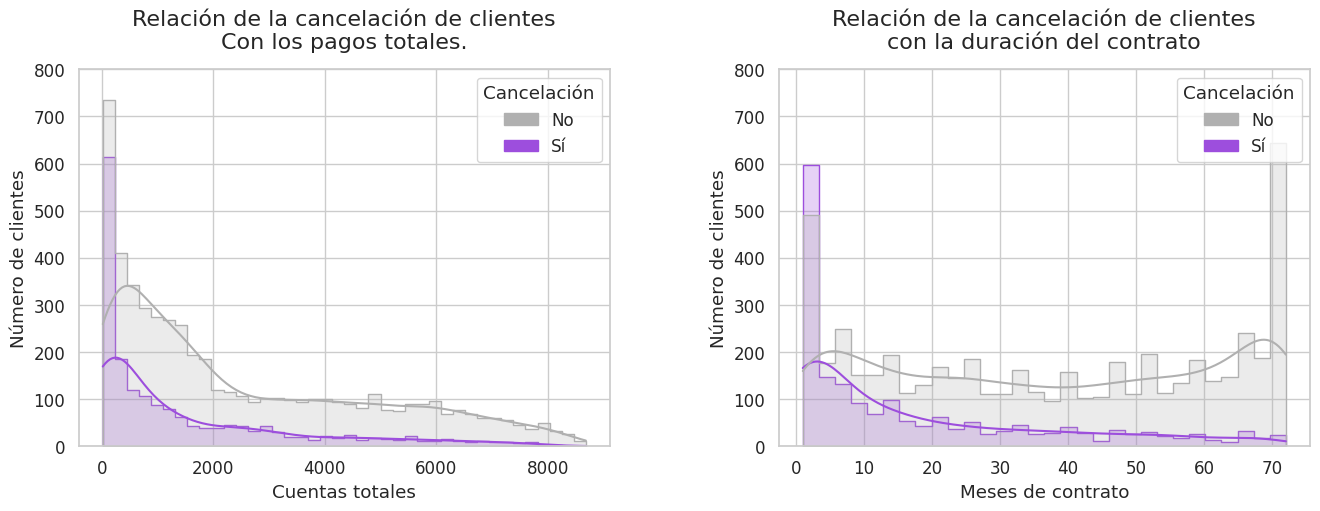

In [131]:
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid", font_scale=1.1)

datos_norm['Cancelacion_txt'] = datos_norm['Cancelación'].map({0: 'No', 1: 'Sí'})

custom_palette = {'No': '#B0B0B0', 'Sí': '#9D4EDD'}

ig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout={'w_pad': 0.5})

# Gráfico 1 -> Gasto total.
sns.histplot(
    data=datos_norm,
    x='Cuentas_totales',
    hue='Cancelacion_txt',
    hue_order=['No', 'Sí'],
    palette=custom_palette,
    bins=40,
    kde=True,
    ax=axes[0],
    element='step'
)

axes[0].set_title('Relación de la cancelación de clientes\nCon los pagos totales.',fontsize = 16, pad = 15)
axes[0].set_xlabel('Cuentas totales')
axes[0].set_ylabel('Número de clientes')
legend_elements = [
    Patch(facecolor='#B0B0B0', edgecolor='#B0B0B0', label='No'),
    Patch(facecolor='#9D4EDD', edgecolor='#9D4EDD', label='Sí')
    ]
axes[0].legend(handles=legend_elements, title='Cancelación')
axes[0].set_ylim(0, 800)

# Gráfico 1 -> Meses contratados
sns.histplot(
    data=datos_norm,
    x='Meses_contrato',
    hue='Cancelacion_txt',
    hue_order=['No', 'Sí'],
    palette=custom_palette,
    bins=30,
    kde=True,
    ax=axes[1],
    element='step'
)

axes[1].set_title('Relación de la cancelación de clientes\ncon la duración del contrato', fontsize = 16, pad = 15)
axes[1].set_xlabel('Meses de contrato')
axes[1].set_ylabel('Número de clientes')
axes[1].legend(handles=legend_elements, title='Cancelación', loc = 'upper right')
axes[1].set_ylim(0, 800)

plt.savefig("grafico_cuentas_tiempo.png", dpi=300, bbox_inches='tight')


# Mostrar gráfico
plt.show()

#📄Informe final

###🔹 Introducción:
El objetivo de este análisis es estudiar el fenómeno de evasión de clientes (Churn) en la empresa TelecomX LATAM.
Éste representa a aquellos clientes que deciden cancelar el servicio, lo cual constituye un problema crítico para las compañías de telecomunicaciones debido al impacto directo en los ingresos y en la estabilidad del negocio.

A través del análisis de datos, se busca identificar patrones y características asociadas a los clientes que abandonan el servicio, con el fin de generar insights accionables que permitan reducir la tasa de cancelación y mejorar la retención de clientes.

La variable objetivo del análisis es:

Churn
*   0 → Cliente permanece
*   1 → Cliente cancela el servicio

###🔹 Limpieza y Tratamiento de Datos:
* Se realizó la importación del conjunto de datos original, seguido de un proceso
exhaustivo de limpieza y transformación:

* Se eliminaron columnas redundantes como Servicio_internet (ya representada por DSL y Fibra_optica).

* Se estandarizaron las variables categóricas y se convirtieron en variables binarias (dummies).

* Se crearon nuevas variables calculadas como "Cuentas_diarias" a partir de los pagos mensuales.

* Se ajustaron los nombres de variables para facilitar su interpretación en las visualizaciones.

* Se normalizaron los nombres de columnas para facilitar el análisis.
###🔹 Conclusiones e Insights:
📌 La antigüedad es uno de los factores más determinantes: clientes nuevos tienen mayor riesgo de cancelación.

📌 Los contratos mensuales presentan mayor churn.

📌 Cargos mensuales altos aumentan la probabilidad de evasión.

📌 Métodos de pago manuales están asociados a mayor cancelación.

📌 Clientes con más servicios contratados tienden a permanecer más tiempo.

Estos hallazgos permiten identificar perfiles de alto riesgo y enfocar estrategias de retención.

###🔹 Recomendaciones:

* En base a los resultados obtenidos, se sugieren las siguientes acciones:

🎯 1. Incentivar contratos a largo plazo

Ofrecer descuentos o beneficios por migrar de contrato mensual a anual.

🎯 2. Programas de retención temprana

Implementar estrategias de fidelización durante los primeros 6–12 meses.

🎯 3. Revisar estructura de precios

Analizar si los cargos mensuales elevados están generando percepción negativa de valor.

🎯 4. Promover pagos automáticos

Ofrecer incentivos por migrar a métodos de pago automáticos.

🎯 5. Ofrecer paquetes de servicios

Clientes con más servicios presentan menor churn, por lo que se pueden crear bundles atractivos.